# Cartoonizer
Upload a selfie, describe your mood, and get a cartoon + mood quote!


**Mounting Drive**

In [ ]:

# Mount Google Drive (optional)
from google.colab import drive
drive.mount('/content/drive/')


Mounted at /content/drive/


**DATA PREPARATION**

In [ ]:
# Clone U-GAT-IT
!git clone https://github.com/znxlwm/UGATIT-pytorch /content/UGATIT

# Install dependencies
!pip install torch torchvision pillow matplotlib tqdm transformers gradio --quiet


Cloning into '/content/UGATIT'...
remote: Enumerating objects: 70, done.
remote: Total 70 (delta 0), reused 0 (delta 0), pack-reused 70 (from 1)
Receiving objects: 100% (70/70), 4.31 MiB | 18.80 MiB/s, done.
Resolving deltas: 100% (23/23), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 116.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os, requests
from PIL import Image
from io import BytesIO

# Create dataset folders
folders = [
    "trainA/real", "trainB/cartoon",
    "testA", "testB"
]
for folder in folders:
    os.makedirs(f"/content/UGATIT/dataset/selfie2anime/{folder}", exist_ok=True)

# Real faces
for i in range(1000):
    r = requests.get("https://thispersondoesnotexist.com", headers={"User-Agent": "Mozilla/5.0"})
    img = Image.open(BytesIO(r.content)).convert("RGB").resize((256, 256))
    img.save(f"/content/UGATIT/dataset/selfie2anime/trainA/real/{i:04d}.jpg")

# Cartoon faces
'''for i in range(50):
    try:
        resp = requests.get("https://api.waifu.pics/sfw/waifu")
        url = resp.json()["url"]
        img_data = requests.get(url).content
        img = Image.open(BytesIO(img_data)).convert("RGB").resize((256, 256))
        img.save(f"/content/UGATIT/dataset/selfie2anime/trainB/cartoon/{i:04d}.jpg")
    except:
        continue'''

for i in range(1000):
    try:
        url = "https://www.thiswaifudoesnotexist.net/example-{}.jpg".format(i)
        img_data = requests.get(url).content
        img = Image.open(BytesIO(img_data)).convert("RGB").resize((256, 256))
        img.save(f"/content/UGATIT/dataset/selfie2anime/trainB/cartoon/{i:04d}.jpg")
    except:
        continue


In [ ]:
from transformers import pipeline

# Load funny caption generator using T5
caption_gen = pipeline("text2text-generation", model="google/flan-t5-base")

def generate_funny_caption(user_text):
    prompt = f"Make this funny: {user_text}"
    result = caption_gen(prompt, max_length=30, do_sample=True)[0]['generated_text']
    return result


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


In [ ]:
import os
os.chdir("/content/drive/MyDrive/cartoonify_15000/UGATIT")


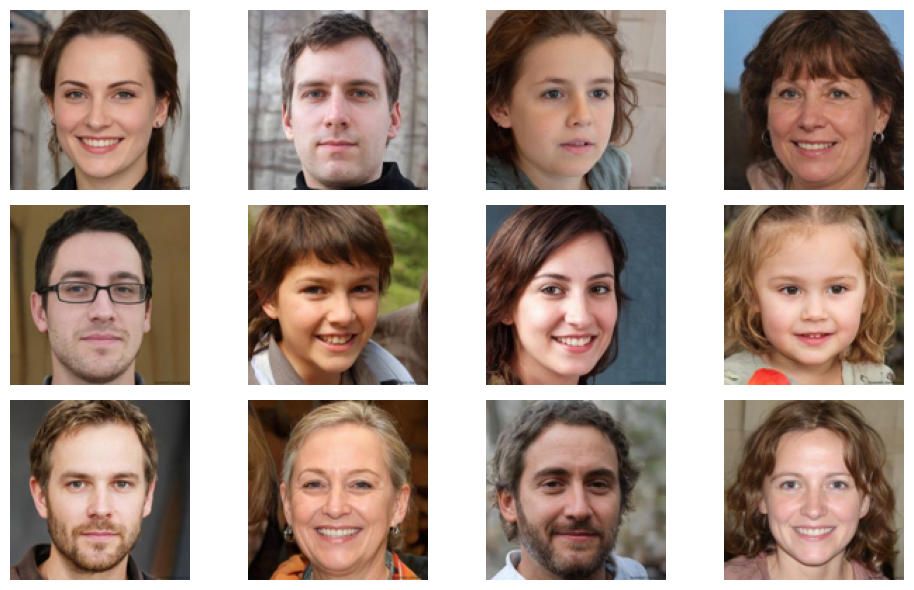

In [ ]:
import os
import random
from PIL import Image as PILImage
import matplotlib.pyplot as plt

# Define the path
folder_path = '/content/drive/MyDrive/cartoonify_15000/UGATIT/dataset/selfie2anime/trainA/real'

# List all image files and select 12 random ones
all_files = os.listdir(folder_path)
image_files = random.sample(all_files, 12)

# Set up grid size
num_images = len(image_files)
cols = 4
rows = (num_images + cols - 1) // cols

# Create the figure
plt.figure(figsize=(10, 6))

for i, file_name in enumerate(image_files):
    file_path = os.path.join(folder_path, file_name)
    img = PILImage.open(file_path).resize((128, 128))

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()


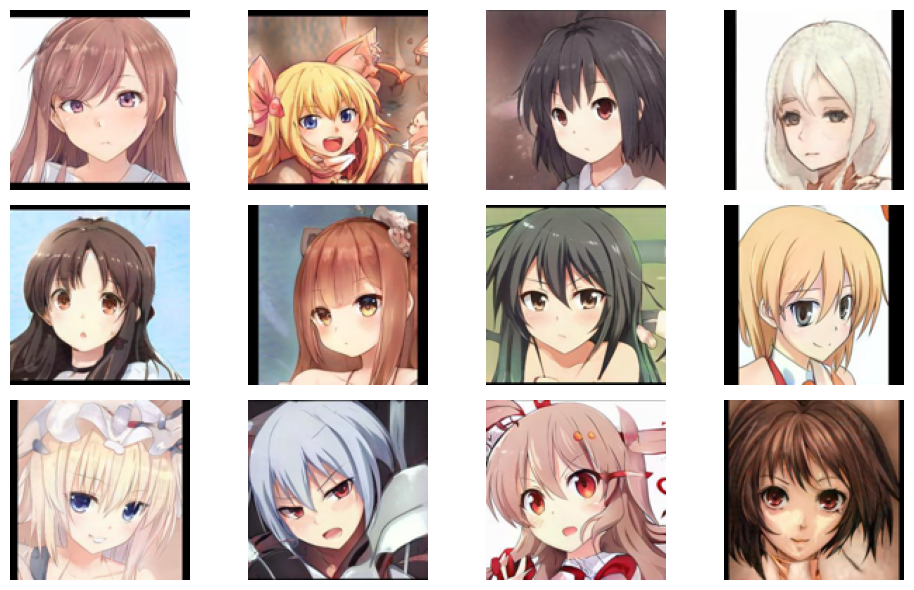

In [ ]:
import os
import random
from PIL import Image as PILImage
import matplotlib.pyplot as plt

# Define the path
folder_path = '/content/drive/MyDrive/cartoonify_15000/UGATIT/dataset/selfie2anime/trainB/cartoon'

# List all image files and select 12 random ones
all_files = os.listdir(folder_path)
image_files = random.sample(all_files, 12)

# Set up grid size
num_images = len(image_files)
cols = 4
rows = (num_images + cols - 1) // cols

# Create the figure
plt.figure(figsize=(10, 6))

for i, file_name in enumerate(image_files):
    file_path = os.path.join(folder_path, file_name)
    img = PILImage.open(file_path).resize((128, 128))

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import os
os.makedirs("/content/drive/MyDrive/cartoonify/UGATIT/dataset/selfie2anime/testA", exist_ok=True)
os.makedirs("/content/drive/MyDrive/cartoonify/UGATIT/dataset/selfie2anime/testB", exist_ok=True)


In [ ]:
from PIL import Image
import os

# Create a dummy white image
dummy = Image.new('RGB', (256, 256), color = 'white')

# Save into both testA and testB folders
os.makedirs("/content/UGATIT/dataset/selfie2anime/testA", exist_ok=True)
os.makedirs("/content/UGATIT/dataset/selfie2anime/testB", exist_ok=True)
dummy.save("/content/UGATIT/dataset/selfie2anime/testA/dummy.jpg")
dummy.save("/content/UGATIT/dataset/selfie2anime/testB/dummy.jpg")


In [ ]:
# Ensure you're in the correct working directory
import os
os.chdir('/content/drive/MyDrive/cartoonify_15000/UGATIT')
# Re-import everything fresh
from UGATIT import UGATIT
from argparse import Namespace
import torch


In [ ]:
import os
os.chdir("/content/drive/MyDrive/cartoonify_15000/UGATIT")

# Configurations
config = Namespace(
    dataset='selfie2anime',
    phase='train',
    light=False,
    ch=64,
    n_res=6,
    n_dis=6,
    img_size=256,
    img_ch=3,
    batch_size=4,
    iteration=15000,
    print_freq=100,
    save_freq=1000,
    decay_flag=True,
    lr=0.0001,
    weight_decay=0.0001,
    adv_weight=1,
    cycle_weight=10,
    identity_weight=10,
    cam_weight=1000,
    result_dir='results/selfie2anime',
    checkpoint_dir='checkpoint/selfie2anime',
    log_dir='log/selfie2anime',
    sample_dir='sample/selfie2anime',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    benchmark_flag=True,
    resume=None
)



In [ ]:
model = UGATIT(config)
model.build_model()

# Verify: these should now work without error
print("✅ Generator:", hasattr(model, 'generatorA2B'))
print("✅ Discriminator:", hasattr(model, 'discriminatorA'))


set benchmark !

##### Information #####
# light :  False
# dataset :  selfie2anime
# batch_size :  4
# iteration per epoch :  15000

##### Generator #####
# residual blocks :  6

##### Discriminator #####
# discriminator layer :  6

##### Weight #####
# adv_weight :  1
# cycle_weight :  10
# identity_weight :  10
# cam_weight :  1000
✅ Generator: False
✅ Discriminator: False


In [ ]:
model = UGATIT(config)
model.build_model()

# 🔍 Print attributes defined in the model
print("Model attributes:")
print([attr for attr in dir(model) if not attr.startswith('_')])


set benchmark !

##### Information #####
# light :  False
# dataset :  selfie2anime
# batch_size :  4
# iteration per epoch :  15000

##### Generator #####
# residual blocks :  6

##### Discriminator #####
# discriminator layer :  6

##### Weight #####
# adv_weight :  1
# cycle_weight :  10
# identity_weight :  10
# cam_weight :  1000
Model attributes:
['BCE_loss', 'D_optim', 'G_optim', 'L1_loss', 'MSE_loss', 'Rho_clipper', 'adv_weight', 'batch_size', 'benchmark_flag', 'build_model', 'cam_weight', 'ch', 'cycle_weight', 'dataset', 'decay_flag', 'device', 'disGA', 'disGB', 'disLA', 'disLB', 'genA2B', 'genB2A', 'identity_weight', 'img_ch', 'img_size', 'iteration', 'light', 'load', 'lr', 'model_name', 'n_dis', 'n_res', 'print_freq', 'result_dir', 'resume', 'save', 'save_freq', 'test', 'testA', 'testA_loader', 'testB', 'testB_loader', 'train', 'trainA', 'trainA_loader', 'trainB', 'trainB_loader', 'weight_decay']


In [ ]:
import os
import torch
import random
import numpy as np
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

# === Set seeds for reproducibility ===
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# === Mixed precision setup ===
scaler = GradScaler()

# === Safe forward helper ===
def safe_forward(out):
    return out if isinstance(out, torch.Tensor) else out[0]

# === Checkpoint save/load ===
def save_checkpoint(model, step, path='checkpoint.pth'):
    torch.save({
        'step': step,
        'genA2B': model.genA2B.state_dict(),
        'genB2A': model.genB2A.state_dict(),
        'disGA': model.disGA.state_dict(),
        'disGB': model.disGB.state_dict(),
        'G_optim': model.G_optim.state_dict(),
        'D_optim': model.D_optim.state_dict(),
        'scaler': scaler.state_dict()
    }, path)
    print(f"💾 Checkpoint saved at step {step}")

def load_checkpoint(model, path='checkpoint.pth'):
    if os.path.exists(path):
        checkpoint = torch.load(path, map_location=model.device)
        model.genA2B.load_state_dict(checkpoint['genA2B'])
        model.genB2A.load_state_dict(checkpoint['genB2A'])
        model.disGA.load_state_dict(checkpoint['disGA'])
        model.disGB.load_state_dict(checkpoint['disGB'])
        model.G_optim.load_state_dict(checkpoint['G_optim'])
        model.D_optim.load_state_dict(checkpoint['D_optim'])
        scaler.load_state_dict(checkpoint['scaler'])
        print(f"📦 Resumed from step {checkpoint['step']}")
        return checkpoint['step']
    return 0

# === Resume if checkpoint exists ===
start_step = load_checkpoint(model, path='checkpoint.pth')

# === Training mode ===
model.genA2B.train()
model.genB2A.train()
model.disGA.train()
model.disGB.train()
model.disLA.train()
model.disLB.train()

# === Loaders ===
trainA_iter = iter(model.trainA_loader)
trainB_iter = iter(model.trainB_loader)

print("🔥 Custom training loop starting...")

try:
    for step in tqdm(range(start_step, config.iteration), initial=start_step):
        try:
            real_A, _ = next(trainA_iter)
        except StopIteration:
            trainA_iter = iter(model.trainA_loader)
            real_A, _ = next(trainA_iter)

        try:
            real_B, _ = next(trainB_iter)
        except StopIteration:
            trainB_iter = iter(model.trainB_loader)
            real_B, _ = next(trainB_iter)

        real_A = real_A.to(model.device, non_blocking=True)
        real_B = real_B.to(model.device, non_blocking=True)

        with autocast():
            # === Generator forward ===
            fake_B = safe_forward(model.genA2B(real_A))
            fake_A = safe_forward(model.genB2A(real_B))

            # === Cycle reconstruction ===
            recon_A = safe_forward(model.genB2A(fake_B))
            recon_B = safe_forward(model.genA2B(fake_A))

            # === Identity losses ===
            idt_A = safe_forward(model.genB2A(real_A))
            idt_B = safe_forward(model.genA2B(real_B))

            cycle_loss = model.L1_loss(recon_A, real_A) + model.L1_loss(recon_B, real_B)
            identity_loss = model.L1_loss(idt_A, real_A) + model.L1_loss(idt_B, real_B)

            pred_fake_A = safe_forward(model.disGA(fake_A))
            pred_fake_B = safe_forward(model.disGB(fake_B))

            valid_A = torch.ones_like(pred_fake_A, device=model.device)
            valid_B = torch.ones_like(pred_fake_B, device=model.device)

            adv_loss = model.MSE_loss(pred_fake_A, valid_A) + model.MSE_loss(pred_fake_B, valid_B)

            G_loss = (
                config.cycle_weight * cycle_loss +
                config.identity_weight * identity_loss +
                config.adv_weight * adv_loss
            )

        model.G_optim.zero_grad()
        scaler.scale(G_loss).backward()
        scaler.step(model.G_optim)

        # === Discriminator forward ===
        with autocast():
            pred_real_A = safe_forward(model.disGA(real_A))
            pred_real_B = safe_forward(model.disGB(real_B))

            fake_A = fake_A.detach()
            fake_B = fake_B.detach()

            pred_fake_A_D = safe_forward(model.disGA(fake_A))
            loss_D_A = 0.5 * (
                model.MSE_loss(pred_real_A, torch.ones_like(pred_real_A, device=model.device)) +
                model.MSE_loss(pred_fake_A_D, torch.zeros_like(pred_fake_A_D, device=model.device))
            )

            pred_fake_B_D = safe_forward(model.disGB(fake_B))
            loss_D_B = 0.5 * (
                model.MSE_loss(pred_real_B, torch.ones_like(pred_real_B, device=model.device)) +
                model.MSE_loss(pred_fake_B_D, torch.zeros_like(pred_fake_B_D, device=model.device))
            )

            D_loss = loss_D_A + loss_D_B

        model.D_optim.zero_grad()
        scaler.scale(D_loss).backward()
        scaler.step(model.D_optim)
        scaler.update()

        # === Logging ===
        if (step + 1) % config.print_freq == 0:
            print(f"Step {step+1}/{config.iteration} | G_loss: {G_loss.item():.4f} | D_loss: {D_loss.item():.4f}")

        # === Checkpointing ===
        if (step + 1) % config.save_freq == 0:
            save_checkpoint(model, step + 1, path='checkpoint.pth')

        # Optional: torch.cuda.empty_cache()  # if GPU memory is tight
        del real_A, real_B, fake_A, fake_B

except KeyboardInterrupt:
    print("⚠️ Training interrupted by user.")
    save_checkpoint(model, step, path='checkpoint.pth')

print("✅ Training complete.")


/tmp/ipython-input-26-193886024.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


🔥 Custom training loop starting...


  0%|          | 0/15000 [00:00<?, ?it/s]/tmp/ipython-input-26-193886024.py:87: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-26-193886024.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
  1%|          | 100/15000 [08:33<21:20:39,  5.16s/it]

Step 100/15000 | G_loss: 8.6684 | D_loss: 0.4684


  1%|▏         | 200/15000 [16:56<20:16:37,  4.93s/it]

...

Step 14900/15000 | G_loss: 3.5709 | D_loss: 0.2607


100%|█████████▉| 14999/15000 [2:56:34<00:00,  2.33it/s]

Step 15000/15000 | G_loss: 3.1521 | D_loss: 0.3874


100%|██████████| 15000/15000 [2:56:56<00:00,  1.41it/s]

💾 Checkpoint saved at step 15000
✅ Training complete.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

torch.save({
    'epoch': current_epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}, '/content/drive/MyDrive/checkpoints/mid_training.pth')


In [ ]:
torch.save(model.genA2B.state_dict(), "genA2B_final.pth")
torch.save(model.genB2A.state_dict(), "genB2A_final.pth")
torch.save(model.disGA.state_dict(), "disGA_final.pth")
torch.save(model.disGB.state_dict(), "disGB_final.pth")
torch.save(model.disLA.state_dict(), "disLA_final.pth")
torch.save(model.disLB.state_dict(), "disLB_final.pth")


In [ ]:
import torch
import os

def get_trained_step(path='checkpoint.pth', device='cpu'):
    if os.path.exists(path):
        checkpoint = torch.load(path, map_location=device)
        step = checkpoint.get('step', None)
        if step is not None:
            print(f"✅ Model was trained up to step: {step}")
        else:
            print("⚠️ Step information not found in checkpoint.")
    else:
        print("❌ Checkpoint file does not exist.")

# Example usage
get_trained_step('checkpoint.pth', device='cuda' if torch.cuda.is_available() else 'cpu')


✅ Model was trained up to step: 15000


In [ ]:
def infer_single_image(self, input_path, save_path):
    from PIL import Image
    import torchvision.transforms as transforms
    self.generatorA2B.eval()

    transform = transforms.Compose([
        transforms.Resize((self.img_size, self.img_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    img = Image.open(input_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(self.device)

    with torch.no_grad():
        out = self.generatorA2B(img_tensor)
    out = (out.squeeze().cpu().numpy().transpose(1, 2, 0) + 1) / 2
    out = (out * 255).astype('uint8')
    Image.fromarray(out).save(save_path)


In [ ]:
import torch
from UGATIT import UGATIT  # or your model path

config.phase = 'test'

# Rebuild the model
inference_model = UGATIT(config)
inference_model.build_model()

# Load generator weights
inference_model.genA2B.load_state_dict(torch.load("/content/drive/MyDrive/cartoonify/UGATIT/genA2B_final.pth"))
inference_model.genA2B.eval()


set benchmark !

##### Information #####
# light :  False
# dataset :  selfie2anime
# batch_size :  4
# iteration per epoch :  15000

##### Generator #####
# residual blocks :  6

##### Discriminator #####
# discriminator layer :  6

##### Weight #####
# adv_weight :  1
# cycle_weight :  10
# identity_weight :  10
# cam_weight :  1000


ResnetGenerator(
  (gap_fc): Linear(in_features=256, out_features=1, bias=False)
  (gmp_fc): Linear(in_features=256, out_features=1, bias=False)
  (conv1x1): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
  (relu): ReLU(inplace=True)
  (gamma): Linear(in_features=256, out_features=256, bias=False)
  (beta): Linear(in_features=256, out_features=256, bias=False)
  (UpBlock1_1): ResnetAdaILNBlock(
    (pad1): ReflectionPad2d((1, 1, 1, 1))
    (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (norm1): adaILN()
    (relu1): ReLU(inplace=True)
    (pad2): ReflectionPad2d((1, 1, 1, 1))
    (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (norm2): adaILN()
  )
  (UpBlock1_2): ResnetAdaILNBlock(
    (pad1): ReflectionPad2d((1, 1, 1, 1))
    (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (norm1): adaILN()
    (relu1): ReLU(inplace=True)
    (pad2): ReflectionPad2d((1, 1, 1, 1))
    (conv2): Conv2d(256, 256,

In [ ]:
import os
import shutil
from PIL import Image as PILImage, ImageDraw, ImageFont
from IPython.display import display
from google.colab import files
import torch
import textwrap
import numpy as np
import torchvision.transforms as transforms
import types

# --- Load trained model for inference ---
config.phase = 'test'
inference_model = UGATIT(config)
inference_model.build_model()
inference_model.genA2B.load_state_dict(torch.load("/content/drive/MyDrive/cartoonify/UGATIT/genA2B_final.pth", map_location=config.device))
inference_model.genA2B.eval()

# --- Define inference method ---
def infer_single_image(self, input_path, output_path):
    self.genA2B.eval()
    transform = transforms.Compose([
        transforms.Resize((self.img_size, self.img_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    image = PILImage.open(input_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(self.device)
    with torch.no_grad():
        output = self.genA2B(tensor)
        if isinstance(output, tuple):
            output = output[0]
        output_image = output.squeeze(0).cpu().detach().numpy()
        output_image = ((output_image + 1) / 2).clip(0, 1)
        output_image = np.transpose(output_image, (1, 2, 0)) * 255
        output_image = PILImage.fromarray(output_image.astype(np.uint8))
        output_image.save(output_path)

# Attach method
inference_model.infer_single_image = types.MethodType(infer_single_image, inference_model)


set benchmark !

##### Information #####
# light :  False
# dataset :  selfie2anime
# batch_size :  4
# iteration per epoch :  15000

##### Generator #####
# residual blocks :  6

##### Discriminator #####
# discriminator layer :  6

##### Weight #####
# adv_weight :  1
# cycle_weight :  10
# identity_weight :  10
# cam_weight :  1000


In [ ]:
def cartoonize_with_funny_caption(user_text, image_path=None):
    if not image_path or not os.path.exists(image_path):
        uploaded = files.upload()
        if not uploaded:
            print("❌ No image uploaded.")
            return
        image_path = list(uploaded.keys())[0]

    caption = generate_funny_caption(user_text)
    print(f"📝 Funny Caption: {caption}")

    input_path = "/content/drive/MyDrive/cartoonify/UGATIT/dataset/selfie2anime/testA/input.jpg"
    cartoon_path = "/content/drive/MyDrive/cartoonify/UGATIT/cartoon_output.jpg"
    final_path = "/content/drive/MyDrive/cartoonify/UGATIT/cartoon_with_caption.jpg"
    shutil.copy(image_path, input_path)

    inference_model.infer_single_image(input_path, cartoon_path)

    img = PILImage.open(cartoon_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype("arial.ttf", 22)
    except:
        font = ImageFont.load_default()

    wrapped_caption = textwrap.fill(caption, width=40)
    text_position = (10, img.height - 60)

    # Shadow
    for dx in [-1, 1]:
        for dy in [-1, 1]:
            draw.text((text_position[0]+dx, text_position[1]+dy), wrapped_caption, font=font, fill="black")
    draw.text(text_position, wrapped_caption, fill="white", font=font)

    img.save(final_path)
    print("✅ Cartoonified image with funny caption:")
    display(img)


In [ ]:
def generate_funny_caption(user_text):
    jokes = {
        "sad": "When you're sad but still photogenic 😢✨",
        "happy": "Smiling harder than my WiFi signal 📶😁",
        "angry": "Angry enough to reboot the universe 😤💥",
        "default": "Just me being animated 🎭"
    }
    return jokes.get(user_text.lower(), f"{user_text.capitalize()}... but make it cartoon.")


Saving 0104.jpg to 0104.jpg
📝 Funny Caption: Smiling harder than my WiFi signal 📶😁
✅ Cartoonified image with funny caption:


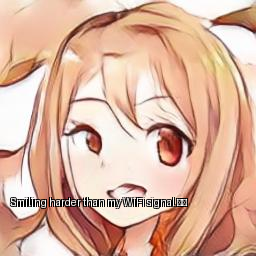

In [ ]:
cartoonize_with_funny_caption("happy")
